In [9]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve().parent.parent / "provided"))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    ARM_LINK,
    CAPTIONS_PATH,
    CARTESIAN_CONTROL_CACHE_PATH,
    ERA_EM_4_PATH,
    FIGURES_PATH,
    MAX_DELTA,
    RANDOM_SEED,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate
from bmi_control import SystemModel

from cartesian_control import (
    NOTEBOOK_GITHUB_URL,
    _eval_trial,
    make_cartesian_control_figure,
    print_metrics,
)

In [10]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
T            = 1000    # steps per trial
DEMO_SEED    = 0       # Brain seed for all evaluation trials
N_SNAPSHOTS  = 6       # arm snapshots in the trajectory panel
TARGET_R_MIN = 20.0    # cm, inner radius of target grid
TARGET_R_MAX = 55.0    # cm, outer radius of target grid
N_R          = 3       # radial rings
N_THETA      = 8       # angular targets per ring
DIST_THRESH  = 10.0    # cm, threshold for time-to-target metric
DEMO_IDX     = 0       # which trial to show in the trajectory panel

# Controller parameters — archive defaults
Q_TRACK         = 10.0
R_EFFORT        = 80.0
Q_INT           = 0.5
EL_THRESH       = 0.15     # rad
SH_THRESH       = 0.15     # rad
SH_DRIFT_THRESH = np.pi / 2    # rad
MIN_PHASE_STEPS = 25
MAX_PHASE_STEPS = 75
SEQ_BLEND_ALPHA = 0.15
SH_VEL_DAMP     = 20.0
EL_HOLD_ALPHA   = 0.4
AMP_REG         = 5e-3

# Per-band amplitude ceilings
A_MAX_SH_POS = 1.0
A_MAX_SH_NEG = 1.0
A_MAX_EL_POS = 1.0
A_MAX_EL_NEG = 1.0

# Per-band gain scaling [S+, S-, E+, E-]
BAND_SCALE = [1, 1, 0.3, 0.3]

# Clip elbow target to [0, π] (anatomical constraint)
CONSTRAIN_ELBOW = False

# Spectral drive mode
# USE_LQI = True  : LQI feedback tracks the spectral target (default)
# USE_LQI = False : open-loop — brain inputs driven directly as sinusoids at
#                   the target frequencies and amplitudes; no Kalman / feedback.
USE_LQI = False

# (n_bands, 2) array of (u0_scale, u1_scale) per band used in open-loop mode.
# None → u0-only [(1, 0)] × n_bands.  Pass best_channels from calibrate_gains()
# for the most selective per-band channel combination.
BAND_CHANNELS: list[tuple[float, float]] | None = None

# DC offset applied to each brain input in open-loop mode (centres sinusoids in [0, 1])
OPEN_LOOP_OFFSET = 0.5

In [11]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
# Load gain-matrix cache
cache = np.load(CARTESIAN_CONTROL_CACHE_PATH)
band_freqs: list[float] = cache["band_freqs"].tolist()
M: np.ndarray = cache["gain_matrix"]
y_mean: np.ndarray = cache["y_mean"]
target_offset: float = float(cache["target_offset"])
x1_proj: np.ndarray | None = cache["x1_proj"] if "x1_proj" in cache else None

if x1_proj is None:
    print("WARNING: x1_proj not found in cache — re-run gain_matrix notebook to regenerate.")

# Load ERA+EM model
est = SystemEstimate.load(ERA_EM_4_PATH)
model = SystemModel.from_estimate(est, y_mean=y_mean)

print("Loaded cache:")
print(f"  band_freqs    : {[f'{f:.4f}' for f in band_freqs]}")
print(f"  gain_matrix M : shape {M.shape}")
print(f"  target_offset : {target_offset:.4f}")
print(f"  y_mean range  : [{y_mean.min():.4f}, {y_mean.max():.4f}]")
print(f"  x1_proj       : {'present' if x1_proj is not None else 'MISSING'}")
print()
print("Gain matrix M  (rad / amplitude unit):")
print(f"{'':12s}" + "".join(f"{n:>10}" for n in ["S+","S-","E+","E-"]))
for j, jname in enumerate(["shoulder", "elbow   "]):
    print(f"  {jname}  " + "".join(f"{M[j,k]:>10.4f}" for k in range(4)))

# Target grid
r_grid     = np.linspace(TARGET_R_MIN, TARGET_R_MAX, N_R)
theta_grid = np.linspace(-np.pi, np.pi, N_THETA, endpoint=False)
R_mg, TH_mg = np.meshgrid(r_grid, theta_grid, indexing="ij")
targets = [
    (float(R_mg[ri, ti] * np.cos(TH_mg[ri, ti])),
     float(R_mg[ri, ti] * np.sin(TH_mg[ri, ti])))
    for ri in range(N_R)
    for ti in range(N_THETA)
]
N_TRIALS = len(targets)
print(f"\n{N_TRIALS} evaluation trials  ({N_R} radii × {N_THETA} angles)")

Loaded cache:
  band_freqs    : ['0.0678', '0.1241', '0.2070', '0.3097']
  gain_matrix M : shape (2, 4)
  target_offset : 4.7068
  y_mean range  : [3.5288, 5.1146]
  x1_proj       : present

Gain matrix M  (rad / amplitude unit):
                    S+        S-        E+        E-
  shoulder      1.5516   -1.5591    0.5476    0.5461
  elbow         0.0000    0.0000    1.5602   -1.4757

24 evaluation trials  (3 radii × 8 angles)


In [12]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
jobs = [
    (
        tgt, i, DEMO_SEED,
        band_freqs, M,
        model.A, model.B, model.C, model.Q, model.R, y_mean,
        target_offset, x1_proj,
        T, ARM_LINK, MAX_DELTA, DIST_THRESH,
        Q_TRACK, R_EFFORT, Q_INT,
        EL_THRESH, SH_THRESH, SH_DRIFT_THRESH,
        MIN_PHASE_STEPS, MAX_PHASE_STEPS,
        SEQ_BLEND_ALPHA, SH_VEL_DAMP, EL_HOLD_ALPHA,
        A_MAX_SH_POS, A_MAX_SH_NEG, A_MAX_EL_POS, A_MAX_EL_NEG,
        AMP_REG,
        BAND_SCALE,
        CONSTRAIN_ELBOW,
        USE_LQI,
        BAND_CHANNELS,
        OPEN_LOOP_OFFSET,
    )
    for i, tgt in enumerate(targets)
]

results: list[dict] = [None] * N_TRIALS  # type: ignore[list-item]

with tqdm(total=N_TRIALS, desc="Evaluating", unit="trial") as pbar:
    for res in Parallel(n_jobs=-1, return_as="generator_unordered")(
        delayed(_eval_trial)(*job) for job in jobs
    ):
        results[res["trial_idx"]] = res
        pbar.set_postfix(
            target=f"({res['target'][0]:.0f},{res['target'][1]:.0f})",
            final_dist=f"{res['dist'][-1]:.1f} cm",
            frac_in=f"{res['frac_in_sector']:.2f}",
        )
        pbar.update(1)

print_metrics(results, T=T, dist_thresh=DIST_THRESH)

Evaluating:   0%|          | 0/24 [00:00<?, ?trial/s]

[seq] elbow→shoulder  step=25  dsh=+1.9106  del=+2.4619  [drift]
[seq] elbow→shoulder  step=25  dsh=-2.2459  del=-1.7913  [drift]
[seq] elbow→shoulder  step=75  dsh=-1.1252  del=-2.4619  [timeout]
[seq] elbow→shoulder  step=75  dsh=+0.4456  del=-2.4619  [timeout]
[seq] shoulder→elbow  step=100  dsh=+1.0414  del=+2.4619  [timeout]
[seq] elbow→shoulder  step=75  dsh=-0.3398  del=-2.4619  [timeout]
[seq] elbow→shoulder  step=75  dsh=-1.2309  del=+2.4609  [timeout]
[seq] elbow→shoulder  step=75  dsh=+0.1103  del=-1.7913  [timeout]
[seq] elbow→shoulder  step=75  dsh=-1.4605  del=-1.7913  [timeout]
[seq] elbow→shoulder  step=75  dsh=+1.1252  del=+2.4588  [timeout]
[seq] elbow→shoulder  step=75  dsh=+0.3398  del=+2.4589  [timeout]
[seq] elbow→shoulder  step=75  dsh=-0.6751  del=-1.7913  [timeout]
[seq] elbow→shoulder  step=75  dsh=-0.4455  del=+2.4595  [timeout]
[seq] shoulder→elbow  step=100  dsh=-1.6629  del=-1.7908  [timeout]
[seq] shoulder→elbow  step=100  dsh=+0.0520  del=-1.6935
[seq] s

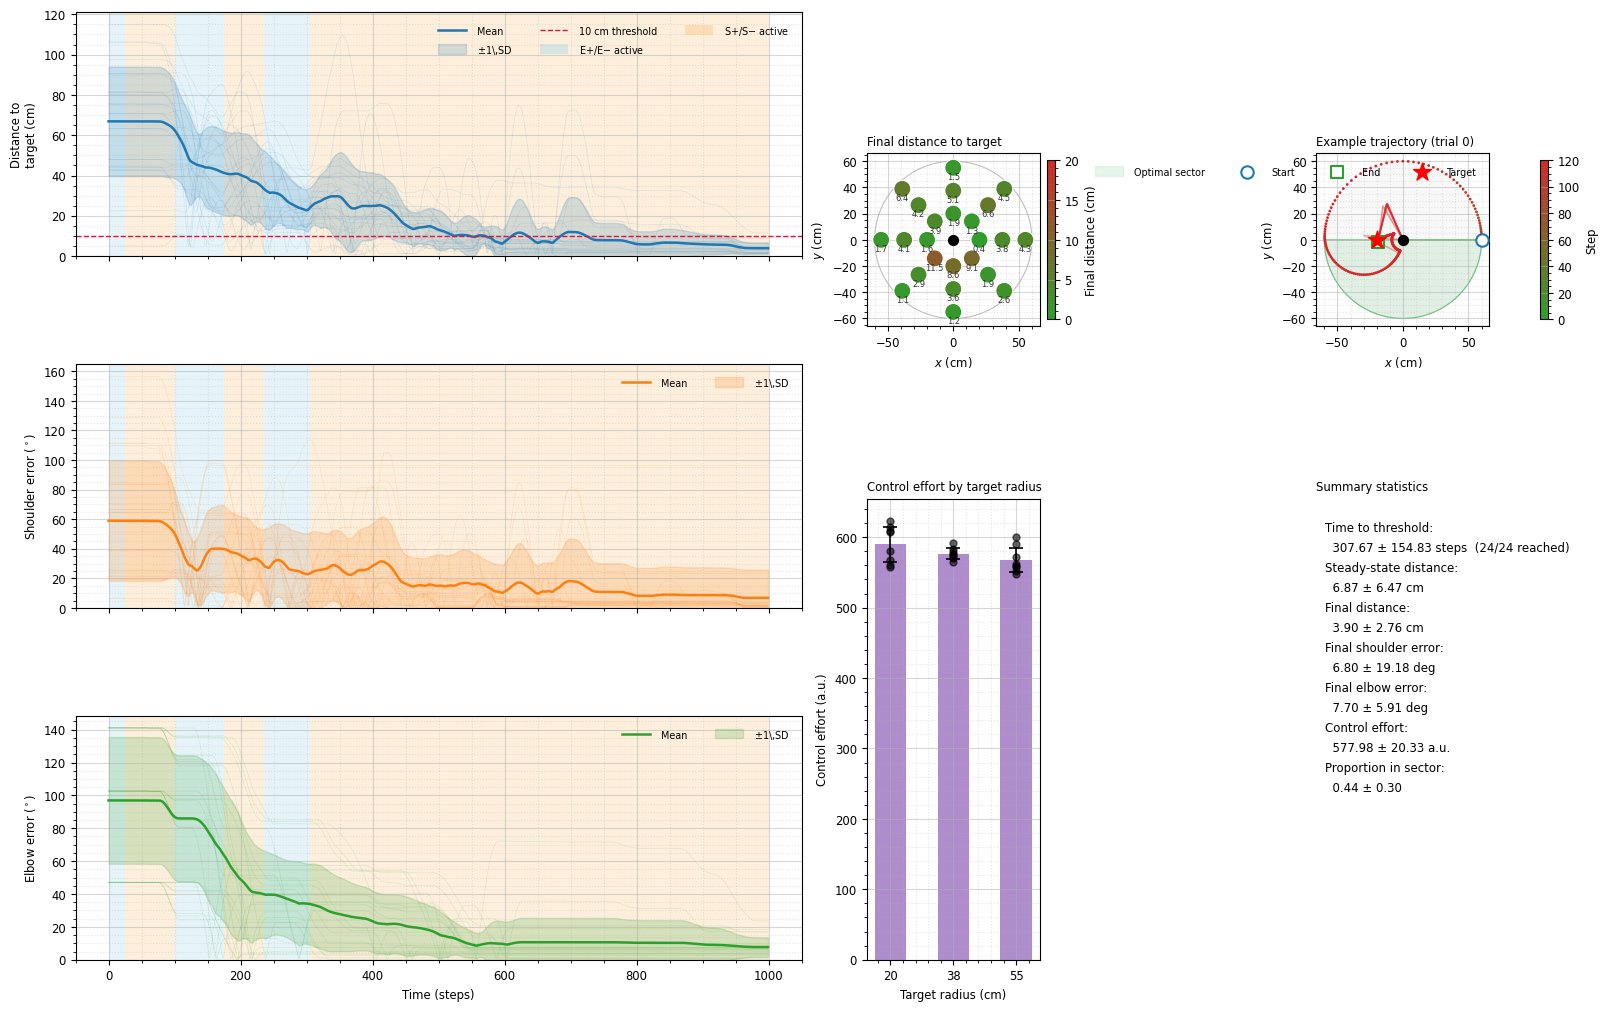

In [13]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_cartesian_control_figure(
    results, targets,
    T=T, arm_link=ARM_LINK, dist_thresh=DIST_THRESH,
    n_r=N_R, n_theta=N_THETA, r_grid=r_grid,
    demo_idx=DEMO_IDX, n_snapshots=N_SNAPSHOTS,
    figsize=(16, 10),
)
apply_figure_style(fig)
plt.show()

In [14]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0
FIG_HEIGHT_FRAC = 0.45

configure_pgf()
fig = make_cartesian_control_figure(
    results, targets,
    T=T, arm_link=ARM_LINK, dist_thresh=DIST_THRESH,
    n_r=N_R, n_theta=N_THETA, r_grid=r_grid,
    demo_idx=DEMO_IDX, n_snapshots=N_SNAPSHOTS,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control.pgf")
plt.close(fig)

/Users/tahmidazam/Developer/gg4/notebooks/shared/pgf_utils.py:96: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(path, backend="pgf", dpi=dpi)


Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control.pgf


In [15]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
import numpy as _np

n_reached   = sum(1 for r in results if r["time_to_thresh"] >= 0)
all_ttt     = [r["time_to_thresh"] for r in results if r["time_to_thresh"] >= 0]
all_fd      = [r["dist"][-1] for r in results]
all_frac_in = [r["frac_in_sector"] for r in results]

caption = (
    r"Cartesian reach evaluation of the sequential LQI controller. "
    f"{N_TRIALS} targets are arranged on a {N_R}\\texttimes{N_THETA} "
    r"polar grid with radii "
    f"$r \\in [{TARGET_R_MIN:.0f}, {TARGET_R_MAX:.0f}]$ cm and angles "
    r"uniformly distributed over $[-\\pi, \\pi)$; each trial runs "
    f"$T={T}$ steps (seed {DEMO_SEED}). "
    r"Top row: distance to target, shoulder error, and elbow error over time; "
    r"individual trials (faint) and mean $\\pm$ 1\\,SD (solid with shading). "
    r"Bottom row (left to right): final distance to target at each grid point; "
    f"example trajectory (trial {DEMO_IDX}) with the optimal sector shaded in "
    r"green and arm snapshots at 6 evenly spaced steps (coloured by time); "
    r"control effort grouped by target radius. "
    r"The elbow target angle is clipped to $[0, \\pi]$ at every step, "
    r"enforcing the anatomical hyperextension constraint. "
    f"{n_reached}/{N_TRIALS} trials reached within {DIST_THRESH:.0f}\\,cm "
    f"(mean time $={_np.mean(all_ttt):.0f}$ steps if any reached); "
    f"mean final distance $={_np.mean(all_fd):.1f}$\\,cm; "
    f"mean proportion of steps in optimal sector $={_np.mean(all_frac_in):.2f}$."
)

save_caption(CAPTIONS_PATH / "cartesian_control.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control.tex
Cartesian reach evaluation of the sequential LQI controller. 24 targets are arranged on a 3\texttimes8 polar grid with radii $r \in [20, 55]$ cm and angles uniformly distributed over $[-\\pi, \\pi)$; each trial runs $T=1000$ steps (seed 0). Top row: distance to target, shoulder error, and elbow error over time; individual trials (faint) and mean $\\pm$ 1\\,SD (solid with shading). Bottom row (left to right): final distance to target at each grid point; example trajectory (trial 0) with the optimal sector shaded in green and arm snapshots at 6 evenly spaced steps (coloured by time); control effort grouped by target radius. The elbow target angle is clipped to $[0, \\pi]$ at every step, enforcing the anatomical hyperextension constraint. 24/24 trials reached within 10\,cm (mean time $=308$ steps if any reached); mean final distance $=3.9$\,cm; mean proportion of steps in optimal sector $=0.44$.


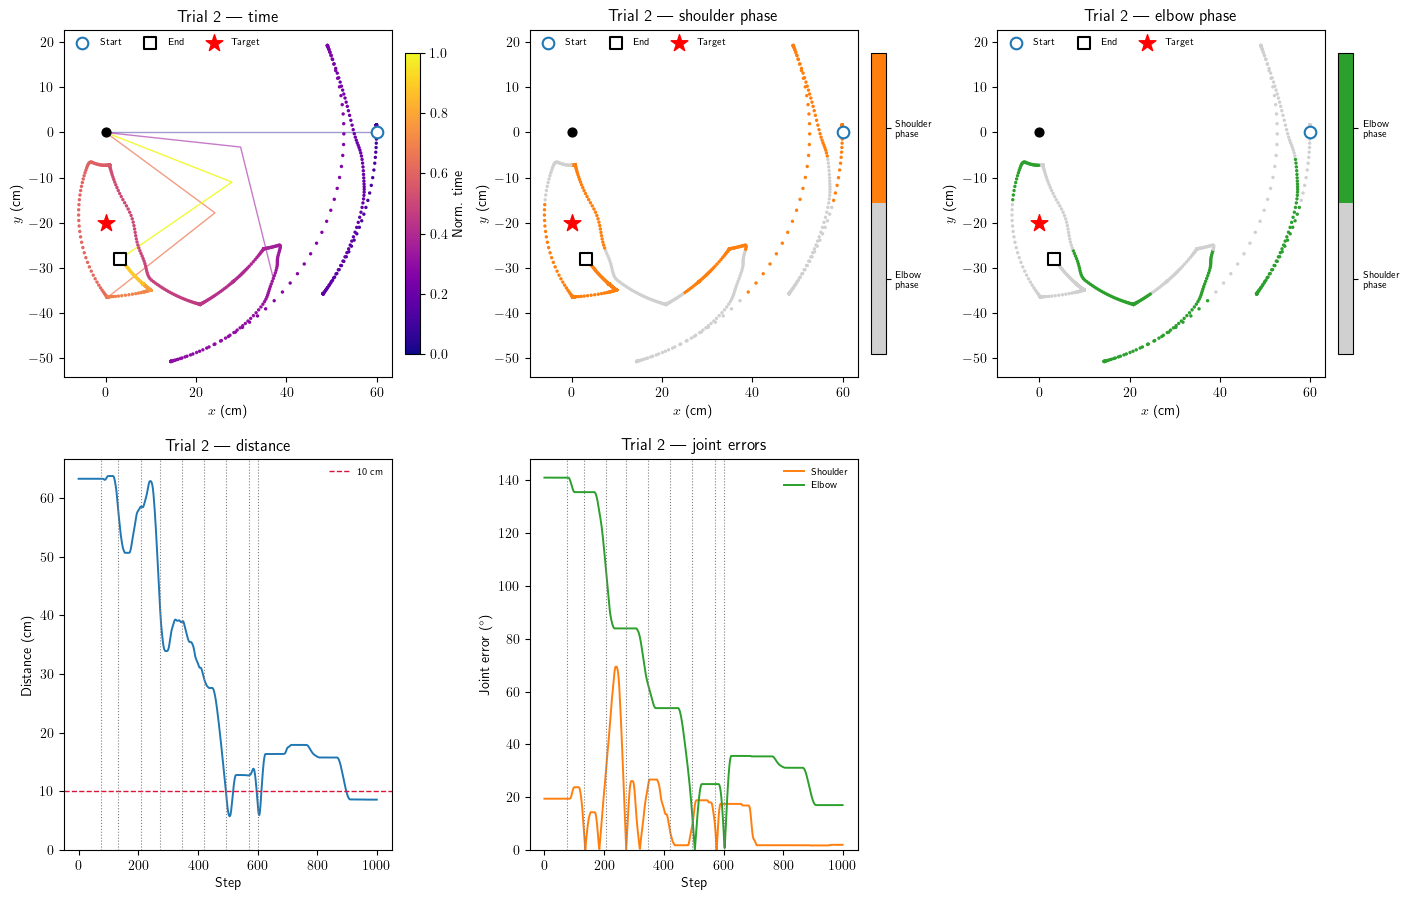

In [17]:
from cartesian_control import debug_plot_trajectories

debug_plot_trajectories(results, index=2, targets=targets, dist_thresh=DIST_THRESH)